In [19]:
import pandas
import numpy as np
data = {'distance':np.random.uniform(1,50,1000),
        'weight':np.random.uniform(1,50,1000),
        'average_speed':np.random.uniform(1,50,1000),
    'vehicle_type':np.random.choice(['bicycle','bike','car'],size=1000)}
speed_factor = {'bicycle': 0.4, 'bike': 0.7, 'car': 1.5}
vehicle_delay = {'bicycle': 50.0, 'bike': 20.0, 'car': 2.0}

data['adjusted_speed'] = [
    s * speed_factor[v] for s, v in zip(data['average_speed'], data['vehicle_type'])
]

data['delivery_time'] = (
    data['distance'] / data['adjusted_speed']
    + np.random.normal(0, 0.3, 1000)
    + [vehicle_delay[v] for v in data['vehicle_type']]
)
data['delivery_time'] += data['weight'] * 0.02
df = pandas.DataFrame(data)
print(df.head())


    distance     weight  average_speed vehicle_type  adjusted_speed  \
0  44.821815  23.752993      11.950229          car       17.925344   
1  42.372549  28.301494      39.577967         bike       27.704577   
2  15.139513   4.885796      29.762858          car       44.644286   
3  46.340841  34.857290      47.448927         bike       33.214249   
4  38.177523   8.795025      39.738418      bicycle       15.895367   

   delivery_time  
0       4.293763  
1      21.518390  
2       1.990914  
3      21.403662  
4      53.024003  


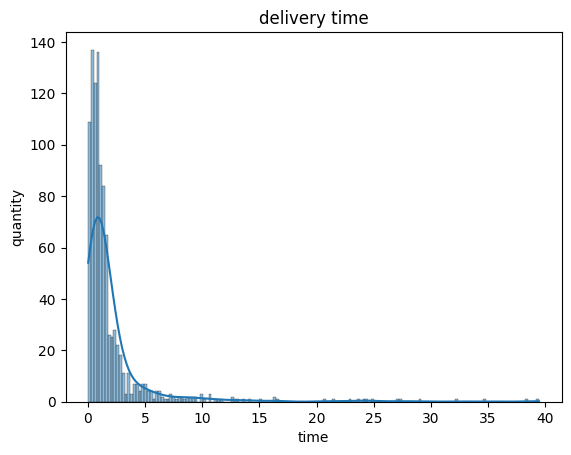

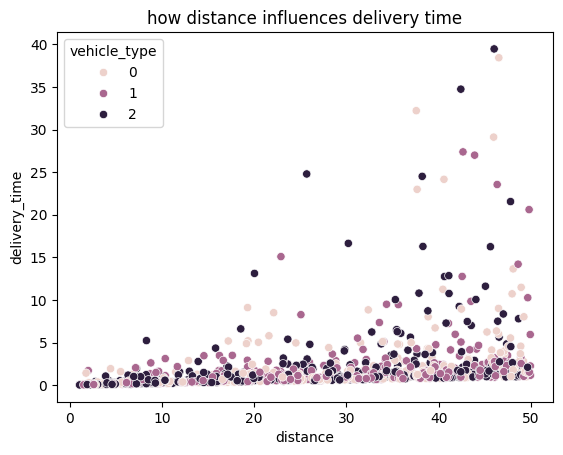

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=df['delivery_time'],kde=True)
plt.title('delivery time')
plt.xlabel('time')
plt.ylabel('quantity')
plt.show()
sns.scatterplot(x='distance',y='delivery_time',hue='vehicle_type',data=df)
plt.title('how distance influences delivery time')
plt.xlabel('distance')
plt.ylabel('delivery_time')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
df['vehicle_type'] = LabelEncoder().fit_transform(df['vehicle_type'])
x=df[['distance','weight','vehicle_type']]
y=df['delivery_time']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
model = RandomForestRegressor(random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
print('mean squared error: ',mse)
print('mean absolute error: ',mae)
importance = pd.Series(model.feature_importances_, index=x.columns)
print(importance.sort_values(ascending=False))

mean squared error:  41.338339746064634
mean absolute error:  2.638440485767834
distance        0.418043
vehicle_type    0.294014
weight          0.287943
dtype: float64


In [12]:
import joblib
joblib.dump(model, 'model_for_predicting_time_of_delivery.pkl')


['model_for_predicting_time_of_delivery.pkl']